# Phase 6 — Segmentation Feasibility Audit

This notebook is a read-only feasibility audit for candidate segmentation annotations. It does not train a U-Net and does not assume that directories named `segmented`, `mask`, or `lesion` contain valid disease-lesion ground truth.

Objective: determine whether the currently available PlantVillage data provides defensible disease-lesion segmentation annotations, or whether the feasibility of later U-Net training remains unestablished.

## Phase 6 final conclusion — segmentation feasibility

Visual inspection of representative original/segmented pairs found corresponding transformed leaf images. The transformation removes or reduces the background while retaining the complete leaf; disease symptoms remain in the retained leaf region. These are leaf/background segmentation outputs, not verified disease-lesion masks. No explicit disease-lesion annotation source was established.

| Capability | Status |
|---|---|
| Original ↔ segmented image pairing | AVAILABLE |
| Leaf/background segmentation | AVAILABLE |
| Verified disease-lesion masks | NOT ESTABLISHED |
| Disease-lesion segmentation dataset | NOT AVAILABLE |
| U-Net disease-lesion training | NOT JUSTIFIED |

U-Net disease-lesion segmentation will not be trained in Phase 6 because genuine disease-lesion ground-truth masks have not been established. The segmented images may be considered for leaf/background preprocessing, but they must not be represented as disease-lesion annotations. Reconsider lesion segmentation only if a genuine lesion-mask dataset is obtained and validated.

In [1]:
!git clone https://github.com/parnikaaa06/tomato-disease-framework.git
%cd tomato-disease-framework

Cloning into 'tomato-disease-framework'...
remote: Enumerating objects: 207, done.
remote: Counting objects: 100% (207/207), done.
remote: Compressing objects: 100% (143/143), done.
remote: Total 207 (delta 70), reused 183 (delta 52), pack-reused 0 (from 0)
Receiving objects: 100% (207/207), 4.25 MiB | 19.26 MiB/s, done.
Resolving deltas: 100% (70/70), done.
/content/tomato-disease-framework


In [2]:
%cd /content/tomato-disease-framework/tomato_disease_framework
!git pull origin main

/content/tomato-disease-framework/tomato_disease_framework
From https://github.com/parnikaaa06/tomato-disease-framework
 * branch            main       -> FETCH_HEAD
Already up to date.


In [3]:
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 25.0 MB/s eta 0:00:00


In [4]:
import torch
import torchvision
import sklearn
import pandas
import yaml
from PIL import Image

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("Environment OK")

torch: 2.11.0+cpu
torchvision: 0.26.0+cpu
Environment OK


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

os.environ["TDF_DATASET_ROOT"] = (
    "/content/drive/.shortcut-targets-by-id/"
    "1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/"
    "PlantVillage/plantvillage dataset/color"
)

dataset_root = os.environ["TDF_DATASET_ROOT"]

print("Dataset root:", dataset_root)
print("Exists:", os.path.isdir(dataset_root))

Dataset root: /content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/color
Exists: True


In [7]:

!python scripts/audit_segmentation_annotations.py

Inspecting dataset root: /content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/color
Inventory written to: results/phase6/segmentation_candidate_inventory.csv
Report written to: results/phase6/segmentation_feasibility_report.yaml

Audit conclusion:
Original-to-segmented pairs are available. Visual inspection of representative pairs shows background removal or reduction while retaining the complete leaf; disease symptoms remain within the retained leaf. The available images represent leaf/background segmentation, not verified disease-lesion masks. No explicit disease-lesion annotation source was established. U-Net disease-lesion training is not justified using the currently established annotations.

Evidence-based answers:
  A: YES
  B: YES (representative pairs confirmed)
  C: YES (leaf/background only)
  D: NOT ESTABLISHED
  E: NOT ESTABLISHED
  F: NOT ESTABLISHED
  G: NOT JUSTIFIED


In [8]:
!find /content/drive -name "segmentation_feasibility_report.yaml" -print 2>/dev/null

/content/drive/MyDrive/UROP_Plant_Disease/results/phase6/segmentation_feasibility_report.yaml


In [9]:
from pathlib import Path
import yaml

report_path = Path(
    "/content/drive/MyDrive/UROP_Plant_Disease/results/phase6/segmentation_feasibility_report.yaml"
)

print("Report exists:", report_path.exists())

with open(report_path, "r", encoding="utf-8") as f:
    report = yaml.safe_load(f)

print(yaml.dump(report, sort_keys=False, default_flow_style=False))

Report exists: True
dataset_root: NOT SET
dataset_root_status: missing
audit_summary:
  status: read-only audit could not inspect dataset files because TDF_DATASET_ROOT
    is missing or invalid.
  source_color_images: 0
  candidate_annotation_files: 0
  matched_pairs: 0
questions:
  A: NOT ESTABLISHED
  B: NOT ESTABLISHED
  C: NOT ESTABLISHED
  D: NOT ESTABLISHED
  E: NOT ESTABLISHED
  F: NOT ESTABLISHED
  G: NOT ESTABLISHED
evidence:
- TDF_DATASET_ROOT was not set or the configured directory does not exist.
- No file-level inspection was performed because no valid source dataset root was
  available.
- Disease-lesion segmentation ground truth remains unverified until actual files are
  inspected.
candidate_collections: []
notes:
- This report intentionally does not infer disease-lesion labels from directory names
  or binary-like image appearance.



In [10]:
import pandas as pd

inventory_path = Path("/content/drive/MyDrive/UROP_Plant_Disease/results/phase6/segmentation_candidate_inventory.csv")

print("Inventory exists:", inventory_path.exists())

inventory = pd.read_csv(inventory_path)

print("Columns:")
print(inventory.columns.tolist())

print("\nNumber of rows:", len(inventory))

display(inventory.head(20))

Inventory exists: True
Columns:
['path', 'file_count', 'file_extensions', 'widths', 'heights', 'modes', 'bands', 'binary_like_count', 'sample_unique_values', 'sample_foreground_background', 'class_counts', 'notes']

Number of rows: 0


,path,file_count,file_extensions,widths,heights,modes,bands,binary_like_count,sample_unique_values,sample_foreground_background,class_counts,notes


In [11]:
from pathlib import Path
import os

dataset_root = Path(os.environ["TDF_DATASET_ROOT"])
dataset_parent = dataset_root.parent

keywords = ["mask", "masks", "segmented", "segmentation", "lesion"]

print("Searching under:")
print(dataset_parent)
print()

candidate_dirs = []

for p in dataset_parent.rglob("*"):
    if p.is_dir() and any(k in p.name.lower() for k in keywords):
        candidate_dirs.append(p)

for p in candidate_dirs:
    print(p)

print("\nCandidate directories found:", len(candidate_dirs))

Searching under:
/content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset

/content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/segmented

Candidate directories found: 1


In [12]:
from PIL import Image
import matplotlib.pyplot as plt

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

candidate_files = []

for d in candidate_dirs:
    for p in d.rglob("*"):
        if p.is_file() and p.suffix.lower() in image_extensions:
            candidate_files.append(p)

print("Candidate image files:", len(candidate_files))

for p in candidate_files[:20]:
    print(p)

Candidate image files: 18167
/content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/cfbf4c76-c9de-43d8-82ce-5a1a64631576___YLCV_NREC 2972_final_masked.jpg
/content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/cfdbbfba-3cdc-4aa2-9c43-cddeff7f6d73___YLCV_NREC 0309_final_masked.jpg
/content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/cfe4a82e-6ed7-44a3-b2d5-ab1cf52df728___YLCV_GCREC 5435_final_masked.jpg
/content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/d0100773-6346-4e0c-aa61-5e19ead5c30f___YLCV_GCREC 2215_final_masked.jpg
/content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh

In [13]:
from pathlib import Path
import yaml

report_path = Path("results/phase6/segmentation_feasibility_report.yaml")

with open(report_path, "r", encoding="utf-8") as f:
    report = yaml.safe_load(f)

print(yaml.dump(report, sort_keys=False, default_flow_style=False))

dataset_root: /content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage
  dataset/color
dataset_root_status: exists
audit_summary:
  status: read-only audit complete
  source_color_images: 18160
  candidate_annotation_files: 63776
  matched_pairs: 27414
  unmatched_candidate_files: 36362
  unmatched_source_images: 4453
  duplicate_stems: &id001 []
  obvious_filename_mismatches: &id002
  - 430dab60-e5fe-4a57-be67-e77bd91f9fda___Keller.St_CG 1772 (1).JPG -> no direct
    source stem match
  - 43660e03-52a8-4451-bcd4-3b4806be2276___Matt.S_CG 6721 (1).JPG -> no direct source
    stem match
  - 441abb22-345f-4188-a6d6-6080e6f08152___JR_Sept.L.S 8479 (1).JPG -> no direct source
    stem match
  - 443ae8f5-c06b-4ed2-af1d-1fd6feddea32___JR_Sept.L.S 2476 (1).JPG -> no direct source
    stem match
  - 54e9c79f-bcce-4744-b5e0-be176d879a30___JR_Sept.L.S 8349 (1).JPG -> no direct source
    stem match
  - 54ed602e-90ce-4d4a-ad50-525dffe24229___Matt.S_CG 7670

In [14]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import os

dataset_root = Path(os.environ["TDF_DATASET_ROOT"])
segmented_root = dataset_root.parent / "segmented"

print("Color root:")
print(dataset_root)

print("\nSegmented root:")
print(segmented_root)

# Get a few candidate files
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

candidate_files = [
    p for p in segmented_root.rglob("*")
    if p.is_file() and p.suffix.lower() in image_exts
]

print("\nCandidate files:", len(candidate_files))

# Inspect first 5
for candidate in candidate_files[:5]:

    # Remove the "_final_masked" suffix to find likely original
    stem = candidate.stem.replace("_final_masked", "")

    class_name = candidate.parent.name
    original = dataset_root / class_name / f"{stem}{candidate.suffix}"

    print("\nCandidate:", candidate.name)
    print("Original candidate:", original)
    print("Original exists:", original.exists())

    if original.exists():
        original_img = Image.open(original)
        candidate_img = Image.open(candidate)

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].imshow(original_img)
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(candidate_img)
        axes[1].set_title("Segmented / Masked")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

Color root:
/content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/color

Segmented root:
/content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/segmented

Candidate files: 18167

Candidate: cfbf4c76-c9de-43d8-82ce-5a1a64631576___YLCV_NREC 2972_final_masked.jpg
Original candidate: /content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/color/Tomato___Tomato_Yellow_Leaf_Curl_Virus/cfbf4c76-c9de-43d8-82ce-5a1a64631576___YLCV_NREC 2972.jpg
Original exists: False

Candidate: cfdbbfba-3cdc-4aa2-9c43-cddeff7f6d73___YLCV_NREC 0309_final_masked.jpg
Original candidate: /content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/color/Tomato___Tomato_Yellow_Leaf_Curl_Virus/cfdbbfba-3cdc-4aa2-9c43-cddeff7f6d73___YLCV_NREC 0309.jpg
Original exists: False

Candidate: cfe4a82e-6ed7-44a3-b2d5-ab1cf52df

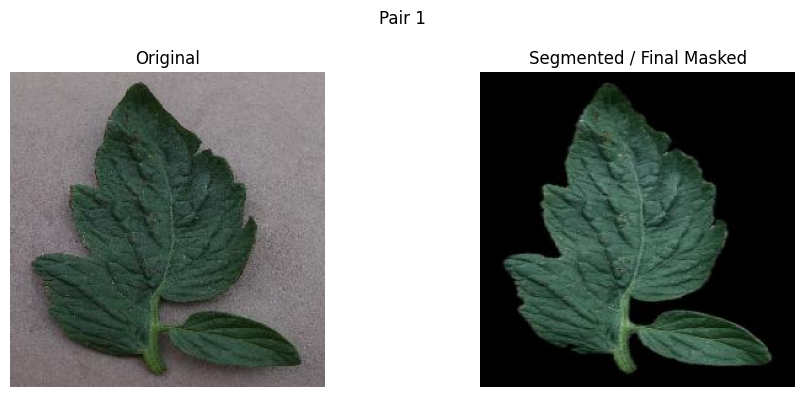

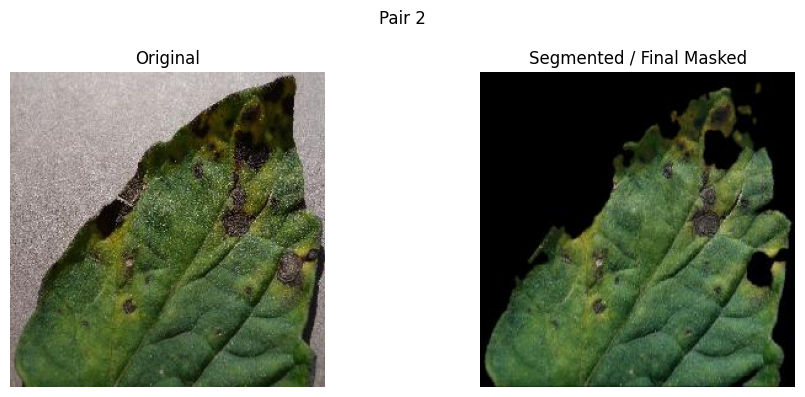

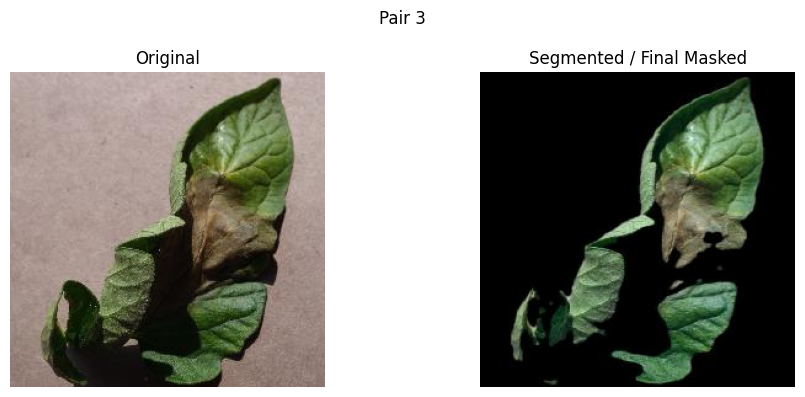

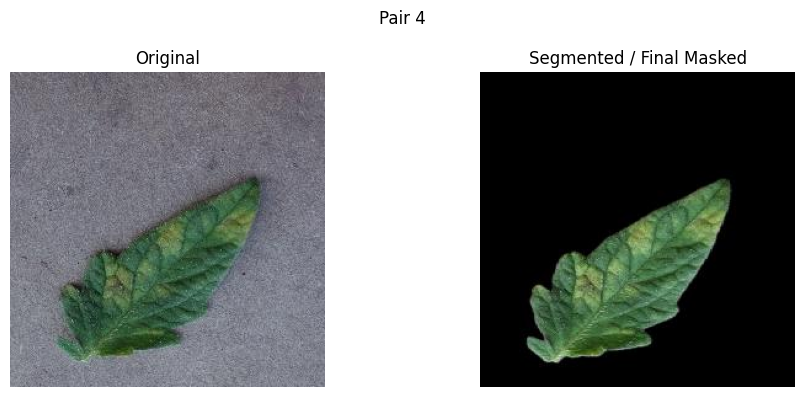

In [16]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

pairs = [
    (
        Path("/content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/color/Tomato___Bacterial_spot/00416648-be6e-4bd4-bc8d-82f43f8a7240___GCREC_Bact.Sp 3110.JPG"),
        Path("/content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/segmented/Tomato___Bacterial_spot/00416648-be6e-4bd4-bc8d-82f43f8a7240___GCREC_Bact.Sp 3110_final_masked.jpg")
    ),
    (
        Path("/content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/color/Tomato___Early_blight/0012b9d2-2130-4a06-a834-b1f3af34f57e___RS_Erly.B 8389.JPG"),
        Path("/content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/segmented/Tomato___Early_blight/0012b9d2-2130-4a06-a834-b1f3af34f57e___RS_Erly.B 8389_final_masked.jpg")
    ),
    (
        Path("/content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/color/Tomato___Late_blight/0003faa8-4b27-4c65-bf42-6d9e352ca1a5___RS_Late.B 4946.JPG"),
        Path("/content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/segmented/Tomato___Late_blight/0003faa8-4b27-4c65-bf42-6d9e352ca1a5___RS_Late.B 4946_final_masked.jpg")
    ),
    (
        Path("/content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/color/Tomato___Leaf_Mold/00694db7-3327-45e0-b4da-a8bb7ab6a4b7___Crnl_L.Mold 6923.JPG"),
        Path("/content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/segmented/Tomato___Leaf_Mold/00694db7-3327-45e0-b4da-a8bb7ab6a4b7___Crnl_L.Mold 6923_final_masked.jpg")
    )
]

for i, (original, segmented) in enumerate(pairs, 1):
    img_original = Image.open(original).convert("RGB")
    img_segmented = Image.open(segmented).convert("RGB")

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img_segmented)
    plt.title("Segmented / Final Masked")
    plt.axis("off")

    plt.suptitle(f"Pair {i}")
    plt.tight_layout()
    plt.show()

In [18]:
from pathlib import Path
import yaml

phase6 = Path(
    "/content/drive/MyDrive/UROP_Plant_Disease/results/phase6"
)

report = phase6 / "segmentation_feasibility_report.yaml"
inventory = phase6 / "segmentation_candidate_inventory.csv"

print("Report exists:", report.exists())
print("Inventory exists:", inventory.exists())

if report.exists():
    with open(report, "r") as f:
        r = yaml.safe_load(f)

    print("\nPhase 6 Questions:")
    print(r.get("questions"))

    print("\nPhase 6 Decision:")
    print(r.get("decision"))

Report exists: True
Inventory exists: True

Phase 6 Questions:
{'A': 'NOT ESTABLISHED', 'B': 'NOT ESTABLISHED', 'C': 'NOT ESTABLISHED', 'D': 'NOT ESTABLISHED', 'E': 'NOT ESTABLISHED', 'F': 'NOT ESTABLISHED', 'G': 'NOT ESTABLISHED'}

Phase 6 Decision:
None


In [19]:
import os
print("TDF_DATASET_ROOT =", os.environ.get("TDF_DATASET_ROOT"))
print("Exists =", os.path.isdir(os.environ.get("TDF_DATASET_ROOT", "")))

TDF_DATASET_ROOT = /content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/color
Exists = True


In [20]:
from pathlib import Path

root = Path(os.environ["TDF_DATASET_ROOT"])

print("Color root:", root)
print("Color files:", len(list(root.rglob("*"))))

seg_root = root.parent / "segmented"

print("Segmented root:", seg_root)
print("Segmented exists:", seg_root.exists())

if seg_root.exists():
    print("Segmented files:", len(list(seg_root.rglob("*"))))

Color root: /content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/color
Color files: 18170
Segmented root: /content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/segmented
Segmented exists: True
Segmented files: 18177


In [21]:

!grep -n "questions" scripts/audit_segmentation_annotations.py
!grep -n "decision" scripts/audit_segmentation_annotations.py
!grep -n "TDF_DATASET_ROOT" scripts/audit_segmentation_annotations.py

348:    """Return evidence-based statuses for the required audit questions."""
400:        questions = decide_statuses(
415:            "questions": questions,
464:    all_questions = decide_statuses(
499:        "questions": all_questions,
577:        print(f"  {key}: {report['questions'][key]}")
428:            "decision": {
511:        "decision": {
9:Python environment where TDF_DATASET_ROOT points at the PlantVillage dataset.
410:                "status": "read-only audit could not inspect dataset files because TDF_DATASET_ROOT is missing or invalid.",
417:                "TDF_DATASET_ROOT was not set or the configured directory does not exist.",
527:    dataset_root_value = os.environ.get("TDF_DATASET_ROOT")
531:        print("TDF_DATASET_ROOT is not set.")
534:        print(f"TDF_DATASET_ROOT does not exist: {dataset_root}")
537:        print(f"TDF_DATASET_ROOT is not a directory: {dataset_root}")


In [22]:
!python scripts/audit_segmentation_annotations.py

Inspecting dataset root: /content/drive/.shortcut-targets-by-id/1TqpwmwVmWbDv2rn_DsNCh1aVjB1QZwca/PlantVillage/plantvillage dataset/color
Inventory written to: results/phase6/segmentation_candidate_inventory.csv
Report written to: results/phase6/segmentation_feasibility_report.yaml

Audit conclusion:
Original-to-segmented pairs are available. Visual inspection of representative pairs shows background removal or reduction while retaining the complete leaf; disease symptoms remain within the retained leaf. The available images represent leaf/background segmentation, not verified disease-lesion masks. No explicit disease-lesion annotation source was established. U-Net disease-lesion training is not justified using the currently established annotations.

Evidence-based answers:
  A: YES
  B: YES (representative pairs confirmed)
  C: YES (leaf/background only)
  D: NOT ESTABLISHED
  E: NOT ESTABLISHED
  F: NOT ESTABLISHED
  G: NOT JUSTIFIED


In [23]:
import yaml

report_path = "results/phase6/segmentation_feasibility_report.yaml"

with open(report_path, "r") as f:
    report = yaml.safe_load(f)

print(report.keys())
print("\nQUESTIONS:")
print(report.get("questions"))

print("\nDECISION:")
print(report.get("decision"))

dict_keys(['dataset_root', 'dataset_root_status', 'audit_summary', 'questions', 'manual_visual_review', 'evidence', 'candidate_collections', 'pairing', 'conclusion', 'decision', 'notes'])

QUESTIONS:
{'A': 'YES', 'B': 'YES (representative pairs confirmed)', 'C': 'YES (leaf/background only)', 'D': 'NOT ESTABLISHED', 'E': 'NOT ESTABLISHED', 'F': 'NOT ESTABLISHED', 'G': 'NOT JUSTIFIED'}

DECISION:
{'original_segmented_pairing': 'AVAILABLE', 'leaf_background_segmentation': 'AVAILABLE', 'verified_disease_lesion_masks': 'NOT ESTABLISHED', 'disease_lesion_segmentation_dataset': 'NOT AVAILABLE', 'unet_disease_lesion_training': 'NOT JUSTIFIED'}
